# Hierarchical IMSTE quality and runtime analysis

Compare exact IMSTE with hierarchical IMSTE over a fixed, stratified digits subset. Each configuration runs with three seeds. The notebook reports per-run metrics and median/IQR summaries, including exact-edge overlap, trustworthiness, a post-fit transductive 5-NN diagnostic, and graph/embedding/total runtimes.

The repeated runs estimate seed sensitivity; three seeds are a small robustness check, not a confidence interval. The exact graph is a fidelity reference, while trustworthiness and 5-NN provide complementary embedding diagnostics. Labels are used only after fitting.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.manifold import trustworthiness
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'mst_embedding').is_dir()),
    None,
)
if repo_root is not None:
    for path in (repo_root, repo_root / 'notebooks'):
        if str(path) not in sys.path:
            sys.path.insert(0, str(path))
from IPython.display import display
from mst_embedding import IteratedMinimumSpanningTreeEmbedder
from hierarchical_quality_utils import run_trials

# Fixed data subset; model seeds vary independently across paired exact/hierarchical runs.
DATA_SEED = 42
SEEDS = (42, 43, 44)
MAX_SAMPLES = 1200  # Set to None to use all 1,797 observations.
N_MSTS = 3
N_EPOCHS = 250
N_CLUSTERS_TO_TRY = [10, 25, 50, 100]
N_COARSE_MSTS = 2
N_LOCAL_MSTS = 3
MINIBATCH_SIZE = 256
N_JOBS = 2
DEVICE = 'cpu'

_digits = load_digits()
X_raw = np.asarray(_digits.data, dtype=np.float64)
y = np.asarray(_digits.target)
if MAX_SAMPLES is not None and MAX_SAMPLES < len(X_raw):
    selected, _ = train_test_split(
        np.arange(len(X_raw)), train_size=MAX_SAMPLES,
        random_state=DATA_SEED, stratify=y,
    )
    X_raw, y = X_raw[selected], y[selected]
X = StandardScaler().fit_transform(X_raw)
print(f'Fixed benchmark data: {len(X):,} samples × {X.shape[1]} features; seeds={SEEDS}')

Fixed benchmark data: 1,200 samples × 64 features; seeds=(42, 43, 44)


## Paired trial protocol

For each seed, exact IMSTE is fitted first and supplies the graph reference for every hierarchical cluster count using that same seed. Each fit is checked for finite coordinates and weights, valid global edge indices, and duplicate undirected edges. A failed configuration is recorded and the sweep continues; if an exact reference fails, hierarchical runs for that seed are recorded as unavailable while other seeds continue.

`graph_construction_time_` covers exact or hierarchical graph building, `embedding_optimization_time_` covers coordinate initialization, negative-sampling preparation, and optimization, and `fit_time_` covers the full estimator fit. `wall_time_seconds` is measured by the notebook around `fit` as an external check.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=DATA_SEED)

def validate_fitted_model(model, n_samples):
    embedding = np.asarray(model.embedding_)
    edges = np.asarray(model.graph_edges_)
    weights = np.asarray(model.graph_weights_)
    if embedding.ndim != 2 or embedding.shape[0] != n_samples:
        raise ValueError(f'Unexpected embedding shape: {embedding.shape}')
    if not np.isfinite(embedding).all():
        raise ValueError('Embedding contains non-finite coordinates.')
    if edges.ndim != 2 or edges.shape[1] != 2 or len(edges) != len(weights):
        raise ValueError('Graph edge and weight arrays have inconsistent shapes.')
    if not np.isfinite(weights).all():
        raise ValueError('Graph weights contain non-finite values.')
    if edges.size:
        if np.any(edges < 0) or np.any(edges >= n_samples):
            raise ValueError('Graph contains an out-of-range sample index.')
        if np.any(edges[:, 0] == edges[:, 1]):
            raise ValueError('Graph contains a self-edge.')
    canonical = [tuple(sorted(map(int, edge))) for edge in edges]
    if len(canonical) != len(set(canonical)):
        raise ValueError('Graph contains duplicate undirected edges.')

    timing_names = (
        'graph_construction_time_',
        'embedding_optimization_time_',
        'fit_time_',
    )
    timings = {name: float(getattr(model, name)) for name in timing_names}
    if not np.isfinite(list(timings.values())).all() or any(v < 0 for v in timings.values()):
        raise ValueError('Fit timing diagnostics must be finite and non-negative.')
    if any(timings[name] > timings['fit_time_'] for name in timing_names[:2]):
        raise ValueError('A stage timing exceeds total fit time.')
    if sum(timings[name] for name in timing_names[:2]) > timings['fit_time_'] + 1e-9:
        raise ValueError('Stage timings exceed total fit time.')
    return set(canonical), timings


def quality_scores(embedding):
    return {
        'trustworthiness': float(trustworthiness(X, embedding, n_neighbors=10)),
        # Transductive diagnostic: the embedding was fitted jointly on all X;
        # labels are used only in this post-fit cross-validation.
        '5NN_accuracy': float(cross_val_score(
            KNeighborsClassifier(n_neighbors=5), embedding, y,
            cv=cv, n_jobs=1,
        ).mean()),
    }


trial_configs = []
for seed in SEEDS:
    trial_configs.append({'mode': 'exact', 'seed': seed, 'n_clusters': None})
    trial_configs.extend(
        {'mode': 'hierarchical', 'seed': seed, 'n_clusters': k}
        for k in N_CLUSTERS_TO_TRY
    )

exact_graphs_by_seed = {}
exact_scores_by_seed = {}
models = {}

def run_one_trial(config):
    mode, seed, n_clusters = config['mode'], config['seed'], config['n_clusters']
    if mode == 'exact':
        estimator = IteratedMinimumSpanningTreeEmbedder(
            graph_mode='exact', n_msts=N_MSTS,
            n_epochs=N_EPOCHS, batch_size=4096,
            random_state=seed, device=DEVICE,
        )
    else:
        if seed not in exact_graphs_by_seed:
            raise RuntimeError('Exact reference failed for this seed.')
        estimator = IteratedMinimumSpanningTreeEmbedder(
            graph_mode='hierarchical', n_clusters=n_clusters,
            n_coarse_msts=N_COARSE_MSTS, n_local_msts=N_LOCAL_MSTS,
            n_jobs=N_JOBS, minibatch_size=MINIBATCH_SIZE,
            n_epochs=N_EPOCHS, batch_size=4096,
            random_state=seed, device=DEVICE,
        )

    wall_started = time.perf_counter()
    estimator.fit(X)
    wall_time = time.perf_counter() - wall_started
    graph_edges, timing = validate_fitted_model(estimator, len(X))
    scores = quality_scores(estimator.embedding_)
    models[(mode, seed, n_clusters)] = estimator

    if mode == 'exact':
        exact_graphs_by_seed[seed] = graph_edges
        exact_scores_by_seed[seed] = scores
        precision = recall = np.nan
        delta_trust = delta_knn = delta_fit = np.nan
    else:
        reference_edges = exact_graphs_by_seed[seed]
        intersection = len(graph_edges & reference_edges)
        precision = intersection / max(len(graph_edges), 1)
        recall = intersection / max(len(reference_edges), 1)
        reference_scores = exact_scores_by_seed[seed]
        delta_trust = scores['trustworthiness'] - reference_scores['trustworthiness']
        delta_knn = scores['5NN_accuracy'] - reference_scores['5NN_accuracy']
        delta_fit = timing['fit_time_'] - models[('exact', seed, None)].fit_time_

    return {
        'mode': mode,
        'seed': seed,
        'n_clusters': n_clusters,
        'unique_edges': len(graph_edges),
        'exact_edge_precision': precision,
        'exact_edge_recall': recall,
        **scores,
        'delta_trustworthiness': delta_trust,
        'delta_5NN_accuracy': delta_knn,
        'delta_fit_time_seconds': delta_fit,
        'graph_construction_seconds': timing['graph_construction_time_'],
        'embedding_optimization_seconds': timing['embedding_optimization_time_'],
        'fit_time_seconds': timing['fit_time_'],
        'wall_time_seconds': wall_time,
    }

runs, failures = run_trials(trial_configs, run_one_trial)
for failure in failures:
    print(
        f"FAILED mode={failure['mode']} seed={failure['seed']} "
        f"clusters={failure['n_clusters']}: "
        f"{failure['error_type']}: {failure['error']}"
    )
runs_df = pd.DataFrame(runs)
failures_df = pd.DataFrame(failures)
print(f'Completed {len(runs)} of {len(trial_configs)} trials; {len(failures)} failed.')
runs_df

Completed 15 of 15 trials; 0 failed.


,mode,seed,n_clusters,unique_edges,exact_edge_precision,exact_edge_recall,trustworthiness,5NN_accuracy,delta_trustworthiness,delta_5NN_accuracy,delta_fit_time_seconds,graph_construction_seconds,embedding_optimization_seconds,fit_time_seconds,wall_time_seconds
0,exact,42,NaN,3597,NaN,NaN,0.954996,0.961667,NaN,NaN,NaN,0.039671,1.038937,1.097082,1.097098
1,hierarchical,42,10.0,4143,0.847454,0.976091,0.815009,0.766667,-0.139988,-0.195000,1.022198,1.781587,0.337600,2.119280,2.119307
2,hierarchical,42,25.0,4389,0.796537,0.971921,0.927634,0.896667,-0.027362,-0.065000,-0.648766,0.067781,0.380433,0.448316,0.448331
3,hierarchical,42,50.0,4643,0.737239,0.951626,0.948664,0.920000,-0.006332,-0.041667,-0.622191,0.065941,0.408871,0.474891,0.474908
4,hierarchical,42,100.0,5109,0.648855,0.921601,0.958390,0.954167,0.003394,-0.007500,-0.571092,0.071460,0.454452,0.525990,0.526006
5,exact,43,NaN,3597,NaN,NaN,0.961032,0.969167,NaN,NaN,NaN,0.034838,0.290614,0.325536,0.325552
6,hierarchical,43,10.0,4113,0.853149,0.975535,0.762807,0.628333,-0.198225,-0.340833,0.101672,0.062583,0.364554,0.427208,0.427222
7,hierarchical,43,25.0,4328,0.805684,0.969419,0.936858,0.916667,-0.024174,-0.052500,0.131395,0.075385,0.381475,0.456932,0.456946
8,hierarchical,43,50.0,4583,0.752127,0.958299,0.946508,0.935000,-0.014524,-0.034167,0.193962,0.082372,0.436937,0.519498,0.519514
9,hierarchical,43,100.0,5105,0.646817,0.917987,0.957298,0.950000,-0.003734,-0.019167,0.184533,0.092143,0.417848,0.510069,0.510083


## Per-run results and seed variability

The table preserves each seed-level result. The summary reports median and interquartile range (25th–75th percentile), plus the number of successful trials. With three seeds these are descriptive variability summaries, not formal confidence intervals. Paired deltas compare each hierarchical run only with exact IMSTE at the same seed.

In [3]:
metric_columns = [
    'unique_edges', 'exact_edge_precision', 'exact_edge_recall',
    'trustworthiness', '5NN_accuracy', 'delta_trustworthiness',
    'delta_5NN_accuracy', 'graph_construction_seconds',
    'embedding_optimization_seconds', 'fit_time_seconds', 'wall_time_seconds',
]

summary_rows = []
if not runs_df.empty:
    for (mode, n_clusters), group in runs_df.groupby(
        ['mode', 'n_clusters'], dropna=False, sort=False
    ):
        row = {
            'mode': mode,
            'n_clusters': n_clusters,
            'successful_runs': len(group),
        }
        for metric in metric_columns:
            values = group[metric].dropna()
            if values.empty:
                continue
            row[f'{metric}_median'] = values.median()
            row[f'{metric}_q25'] = values.quantile(0.25)
            row[f'{metric}_q75'] = values.quantile(0.75)
        summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df

# Failures remain visible even when some configurations succeeded.
if not failures_df.empty:
    display(failures_df)


## Compare quality and runtime

For quality, inspect graph overlap alongside trustworthiness and the post-fit 5-NN diagnostic. For runtime, compare full `fit_time_` and the measured graph/embedding stages. The first parallel run can include worker startup overhead; the median across seeds reduces sensitivity to a single timing outlier.

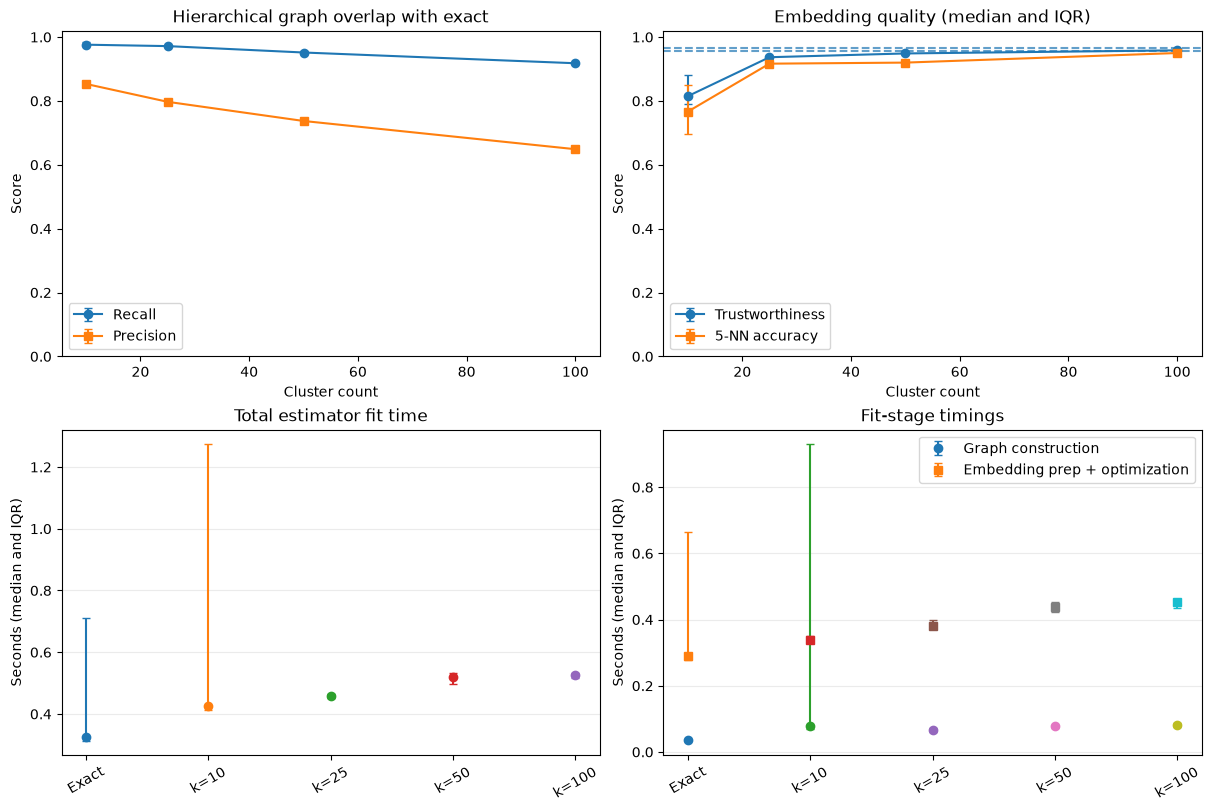

KeyError: "['delta_fit_time_seconds_median', 'delta_fit_time_seconds_q25', 'delta_fit_time_seconds_q75'] not in index"

In [4]:
def plot_median_iqr(ax, frame, x, metric, label, marker='o'):
    frame = frame.sort_values(x)
    median = frame[f'{metric}_median'].to_numpy(dtype=float)
    low = median - frame[f'{metric}_q25'].to_numpy(dtype=float)
    high = frame[f'{metric}_q75'].to_numpy(dtype=float) - median
    ax.errorbar(frame[x], median, yerr=np.vstack([low, high]), marker=marker, capsize=3, label=label)

hier = summary_df[summary_df['mode'] == 'hierarchical'].copy() if not summary_df.empty else pd.DataFrame()
exact = summary_df[summary_df['mode'] == 'exact'] if not summary_df.empty else pd.DataFrame()
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

if not hier.empty:
    plot_median_iqr(axes[0, 0], hier, 'n_clusters', 'exact_edge_recall', 'Recall')
    plot_median_iqr(axes[0, 0], hier, 'n_clusters', 'exact_edge_precision', 'Precision', marker='s')
    axes[0, 0].set(title='Hierarchical graph overlap with exact', xlabel='Cluster count', ylabel='Score')
    axes[0, 0].set_ylim(0, 1.02)
    axes[0, 0].legend()

    for metric, label, marker in [
        ('trustworthiness', 'Trustworthiness', 'o'),
        ('5NN_accuracy', '5-NN accuracy', 's'),
    ]:
        plot_median_iqr(axes[0, 1], hier, 'n_clusters', metric, label, marker)
        if not exact.empty:
            axes[0, 1].axhline(exact.iloc[0][f'{metric}_median'], linestyle='--', alpha=0.7)
    axes[0, 1].set(title='Embedding quality (median and IQR)', xlabel='Cluster count', ylabel='Score')
    axes[0, 1].set_ylim(0, 1.02)
    axes[0, 1].legend()

# Runtime category plots include exact and every successful hierarchical configuration.
plot_rows = []
for _, row in summary_df.iterrows():
    label = 'Exact' if row['mode'] == 'exact' else f"k={int(row['n_clusters'])}"
    plot_rows.append((label, row))
labels = [item[0] for item in plot_rows]
positions = np.arange(len(plot_rows))
for ax, metric, title in [
    (axes[1, 0], 'fit_time_seconds', 'Total estimator fit time'),
]:
    for i, (_, row) in enumerate(plot_rows):
        med, q25, q75 = (row[f'{metric}_{suffix}'] for suffix in ('median', 'q25', 'q75'))
        ax.errorbar(i, med, yerr=[[med - q25], [q75 - med]], fmt='o', capsize=3)
    ax.set_xticks(positions, labels, rotation=30)
    ax.set_title(title)
    ax.set_ylabel('Seconds (median and IQR)')
    ax.grid(axis='y', alpha=0.25)

for i, (_, row) in enumerate(plot_rows):
    for metric, marker, label in [
        ('graph_construction_seconds', 'o', 'Graph construction'),
        ('embedding_optimization_seconds', 's', 'Embedding prep + optimization'),
    ]:
        med, q25, q75 = (row[f'{metric}_{suffix}'] for suffix in ('median', 'q25', 'q75'))
        axes[1, 1].errorbar(i, med, yerr=[[med - q25], [q75 - med]], fmt=marker, capsize=3, label=label if i == 0 else None)
axes[1, 1].set_xticks(positions, labels, rotation=30)
axes[1, 1].set_title('Fit-stage timings')
axes[1, 1].set_ylabel('Seconds (median and IQR)')
axes[1, 1].grid(axis='y', alpha=0.25)
axes[1, 1].legend()
plt.show()

paired_deltas = summary_df[summary_df['mode'] == 'hierarchical'][[
    'n_clusters', 'successful_runs',
    'delta_trustworthiness_median', 'delta_trustworthiness_q25', 'delta_trustworthiness_q75',
    'delta_5NN_accuracy_median', 'delta_5NN_accuracy_q25', 'delta_5NN_accuracy_q75',
    'delta_fit_time_seconds_median', 'delta_fit_time_seconds_q25', 'delta_fit_time_seconds_q75',
]] if not summary_df.empty else pd.DataFrame()
paired_deltas

## Reading the results

Prefer cluster settings that retain embedding quality while reducing total time. High exact-edge recall alone does not establish a good embedding, and these digits results do not guarantee performance on the 50k-sample image workload. Review failed trials before comparing summaries; configurations with fewer than three successful seeds have weaker robustness evidence.